# EDA

## Initial Exploration

In [1]:
import pandas as pd
import os

In [2]:
df_qs = pd.read_csv("../data/raw/2023_volunteering_survey.csv")

In [3]:
df_qs.head()

,Analysis Variable Name,Original Variable Name,Variable Type,Format Name,Label,Full Question Text/Census Codebook Label,In 2017 dataset,In 2019 dataset,In 2021 dataset,In 2023 dataset,Notes
0,supwgt,pwnrwgt,Numeric,NaN,Nonresponse supplement weight,Nonresponse supplement weight,True,True,True,True,Use with supplement variables pes1-pes18 and p...
1,ssupwgt,pwsrwgt,Numeric,NaN,Self-response supplement weight,Self-response supplement weight,False,False,True,True,Use with supplement variables only asked of se...
2,workpride,peswp1a,Categorical,agree,I am proud to be working for my employer,Now I'm going to read you a list of statements...,False,False,True,True,NaN
3,yesworkpride,peswp1a,Binary,dummy,Proud to be working for employer [peswp1a>=agree],NaN,False,False,True,True,NaN
4,workcont,peswp1b,Categorical,agree,My workplace contributes to the community,Now I'm going to read you a list of statements...,False,False,True,True,NaN


In [4]:
df = pd.read_csv("../data/raw/1_cpssep2023.csv")

/tmp/ipykernel_15837/882832440.py:1: DtypeWarning: Columns (0: hutypea, 1: hutypc, 2: pubus2ot, 3: pubusck2, 4: pehrusl2, 5: pulaydt, 6: pulay6m, 7: pelayavl, 8: pulayavr, 9: pelaylk, 10: pelaydur, 11: pelayfto, 12: pulayck1, 13: pulayck2, 14: pulayck3, 15: pulkm4, 16: pulkm5, 17: pulkm6, 18: pulkdk1, 19: pulkps1, 20: pulkps2, 21: pulkps3, 22: pulkps4, 23: pulkavr, 24: pelkll2o, 25: pelkdur, 26: pedwlkwk, 27: pedwavr, 28: pudwck2, 29: pudwck3, 30: pujhdp1o, 31: pejhrsn, 32: pujhck3, 33: pujhck5, 34: peafwhn3, 35: peafwhn4, 36: ptnmemp1, 37: pepdemp2, 38: ptnmemp2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/1_cpssep2023.csv")


In [5]:
df.shape

(126665, 456)

In [6]:
df.head()

,hrhhid,hrmonth,hryear4,hurespli,hufinal,hetenure,hehousut,hetelhhd,hetelavl,hephoneo,...,white,black,hispanic,female,simedu,employed,parent,schoolparent,topmsa,simfaminc
0,107009681110850,9,2023,1,CAPI COMPLETE,OWNED OR BEING BOUGHT BY A HH MEMBER,"HOUSE, APARTMENT, FLAT",YES,-1,YES,...,Yes,No,No,No,"Associate degree, academic",No,No,No,.u,"$40,000 to $59,999"
1,107009681110850,9,2023,1,CAPI COMPLETE,OWNED OR BEING BOUGHT BY A HH MEMBER,"HOUSE, APARTMENT, FLAT",YES,-1,YES,...,Yes,No,No,Yes,High school graduate,No,No,No,.u,"$40,000 to $59,999"
2,51270501771001,9,2023,-1,VACANT REGULAR,-1,"HOUSE, APARTMENT, FLAT",-1,-1,0,...,.u,.u,.u,.u,.u,.u,No,No,.u,.u
3,177071021000551,9,2023,-1,VACANT REGULAR,-1,"HOUSE, APARTMENT, FLAT",-1,-1,0,...,.u,.u,.u,.u,.u,.u,No,No,.u,.u
4,410101640403401,9,2023,-1,VACANT REGULAR,-1,"HOUSE, APARTMENT, FLAT",-1,-1,0,...,.u,.u,.u,.u,.u,.u,No,No,.u,.u


I will analyze statistical decriptions and null counts after paring down the columns to relevant material.

Only working with the 2023 responses, so will slim `df_qs` down to only variables included in that survey ("In 2023 dataset" == True).

In [7]:
df_names = df_qs[df_qs["In 2023 dataset"] == True][["Analysis Variable Name", "Original Variable Name", "Label"]]

Some features were renamed between the collection of responses and the creation of the repsonse table. Below those changes (that are available programmatically) are shown.

In [8]:
for v in df_names['Original Variable Name'].unique():
    try:
        print(df[v].head(1))
        print(df_names[df_names['Original Variable Name'] == v]['Label'])
        print("\n")
    except:
        ve = df_names[df_names['Original Variable Name'] == v]['Analysis Variable Name'].iloc[0]
        print(f"{v} renamed for analysis to: {ve}")
        print(df[ve].head(1))
        print(df_names[df_names['Original Variable Name'] == v]['Label'])
        print("\n")

pwnrwgt renamed for analysis to: supwgt
0    2231.7972
Name: supwgt, dtype: float64
0    Nonresponse supplement weight
Name: Label, dtype: str


pwsrwgt renamed for analysis to: ssupwgt
0    2897.7414
Name: ssupwgt, dtype: float64
1    Self-response supplement weight
Name: Label, dtype: str


peswp1a renamed for analysis to: workpride
0    .u
Name: workpride, dtype: str
2             I am proud to be working for my employer
3    Proud to be working for employer [peswp1a>=agree]
Name: Label, dtype: str


peswp1b renamed for analysis to: workcont
0    .u
Name: workcont, dtype: str
4            My workplace contributes to the community
5    Workplace contributes to the community [peswp1...
Name: Label, dtype: str


peswp1c renamed for analysis to: worksat
0    .u
Name: worksat, dtype: str
6         My main satisfaction in life comes from work
7    Main satisfaction in life comes from work [pes...
Name: Label, dtype: str


peswp1d renamed for analysis to: workicont
0    .u
Name: workicont,

## Narrowing the Dataset

Many of these columns contain metadata about the interviewing process of the survey, which is not useful for this analysis. Later in the analysis, there will be several columns I need to one-hot encode, and I want to try and mitigate wide dataset issues as much as possible before hitting that step. I will be parsing through the columns and consulting supplemental documents to the data (cpssep23.pdf and the qs_df above) to determine what can be dropped.

In [9]:
_ = 0

In [10]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,hrhhid,hrmonth,hryear4,hurespli,hufinal,hetenure,hehousut,hetelhhd,hetelavl,hephoneo,hefaminc,hutypea,hutypb,hutypc,hwhhwgt
0,107009681110850,9,2023,1,CAPI COMPLETE,OWNED OR BEING BOUGHT BY A HH MEMBER,"HOUSE, APARTMENT, FLAT",YES,-1,YES,"50,000 TO 59,999",-1,-1,-1,2010.6736


In the first 15 columns, useful housing type information can be gained from `hetenure` and `hehousut`, and income class can be pulled from `hefaminc`*; the rest are specific interview details and can be dropped.

\* `hefaminc` has a note in the supplemental documents that it should be used with caution, as there is approximately a 20% allocation rate on this feature. We will look at this later to determine how / if it should be included in analysis.

In [11]:
cols_copy = []

In [12]:
cols_copy_1 = ["hetenure", "hehousut", "hefaminc"]

for c in cols_copy_1:
    cols_copy.append(c)

In [13]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,hrintsta,hrnumhou,hrhtype,hrmis,huinttyp,huprscnt,hrlonglk,hrhhid2,hwhhwtln,hubus,hubusl1,hubusl2,hubusl3,hubusl4,gereg
0,INTERVIEW,2,UNMARRIED CIVILIAN MALE-PRIM. FAM HHLDER,6,TELEPHONE,0,MIS 2-4 OR MIS 6-8,15011,1,NO,-1,-1,-1,-1,SOUTH


In the next chunk, `hrnumhou` gives household size information that could be useful, and `hubus` lets us know if the individual's household has a business/farm owner. I will also use `gereg` to get a general sense of location, the regions within this feature share similar cultural characteristics that I'm curious to see what the results reflect from them. The rest can be dropped.

In [14]:
cols_copy_2 = ["hrnumhou", "hubus", "gereg"]

for c in cols_copy_2:
    cols_copy.append(c)

In [15]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,gediv,state,gtcbsa,gtco,gtcbsast,gtmetsta,gtindvpc,gtcbsasz,gtcsa,perrp,prtage,prtfage,pemaritl,pespouse,pesex
0,EAST SOUTH CENTRAL,AL,33860,NOT IDENTIFIED,BALANCE,METROPOLITAN,"NOT IDENTIFIED, NONMETROPOLITAN,","250,000 - 499,999",NOT IDENTIFIED OR NONMETROPOLITAN,REFERENCE PERSON W/RELS.,85+ Years Old,TOP CODED VALUE FOR AGE,WIDOWED,NO SPOUSE,MALE


This chunk continues to drill down in geographic detail for interviewees. I want to keep `gtmetsta`, which codes the location as being metropolitan or nonmetropolitan. I also want to keep `prtage` (age), `pemaritl` (marital status), and `pesex` (sex binary). The rest can be dropped.

In [16]:
cols_copy_3 = ["gtmetsta", "prtage", "pemaritl", "pesex"]

for c in cols_copy_3:
    cols_copy.append(c)

In [17]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,veteran,peafnow,peeduca,ptdtrace,prdthsp,puchinhh,pulineno,prfamnum,prfamrel,prfamtyp,pehspnon,prmarsta,prpertyp,penatvty,pemntvty
0,Yes,NO,ASSOCIATE DEGREE-ACADEMIC PROGRAM,White Only,-1,CHANGE IN DEMOGRAPHIC INFORMATION,1,PRIMARY FAMILY MEMBER ONLY,REFERENCE PERSON,PRIMARY FAMILY,NON-HISPANIC,WIDOWED,ADULT CIVILIAN HOUSEHOLD MEMBER,UNITED STATES,UNITED STATES


`veteran` and `peafnow` tell us the veteran / active duty status of the person responding; `peeduca` tells us their highest completed level of education; `ptdtrace` and `pehspnon` give us racial / ethnicity details. The rest of this chunk can be discarded.

In [18]:
cols_copy_4 = ["veteran", "peafnow", "peeduca", "ptdtrace", "pehspnon"]

for c in cols_copy_4:
    cols_copy.append(c)

In [19]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,pefntvty,prcitshp,prcitflg,prinusyr,puslfprx,pemlr,puwk,pubus1,pubus2ot,pubusck1,pubusck2,pubusck3,pubusck4,puretot,pudis
0,UNITED STATES,"NATIVE, BORN IN THE UNITED STATES",0,NOT FOREIGN BORN,SELF,NOT IN LABOR FORCE-RETIRED,RETIRED,-1,-1,GOTO PURETCK1,-1,-1,-1,YES,-1


`prcitshp` provides citizenship status of the person responding. We then enter labor force items. `pemlr` codes employment status. The rest is either redundant or interview instructions and can be dropped.

In [20]:
cols_copy_5 = ["prcitshp", "pemlr"]

for c in cols_copy_5:
    cols_copy.append(c)

In [21]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,peret1,pudis1,pudis2,puabsot,pulay,peabsrsn,peabspdo,pemjot,pemjnum,pehrusl1,pehrusl2,pehrftpt,pehruslt,pehrwant,pehrrsn1
0,NO,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


`pemjot` codes for people holding multiple jobs, `pehruslt` says how many hours a week the person works, the rest include responses to specific answers earlier in the questionnaire and can be removed.

In [22]:
cols_copy_6 = ["pemjot", "pehruslt"]

for c in cols_copy_6:
    cols_copy.append(c)

In [23]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,pehrrsn2,pehrrsn3,puhroff1,puhroff2,puhrot1,puhrot2,pehract1,pehract2,pehractt,pehravl,puhrck1,puhrck2,puhrck3,puhrck4,puhrck5
0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


These are all follow-up questions or instructions and can be dropped.

In [24]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,puhrck6,puhrck7,puhrck12,pulaydt,pulay6m,pelayavl,pulayavr,pelaylk,pelaydur,pelayfto,pulayck1,pulayck2,pulayck3,pulk,pelkm1
0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


These are all follow-up questions or instructions and can be dropped.

In [25]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,pulkm2,pulkm3,pulkm4,pulkm5,pulkm6,pulkdk1,pulkdk2,pulkdk3,pulkdk4,pulkdk5,pulkdk6,pulkps1,pulkps2,pulkps3,pulkps4
0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


These are all asking for ways people, based on previous answers, searching for work have done so. Can be dropped.

In [26]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,pulkps5,pulkps6,pelkavl,pulkavr,pelkll1o,pelkll2o,pelklwo,pelkdur,pelkfto,pedwwnto,pedwrsn,pedwlko,pedwwk,pedw4wk,pedwlkwk
0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


A couple more job search checks, then several questions about desire to find work and duration of unemployment, all drops.

In [27]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,pedwavl,pedwavr,pudwck1,pudwck2,pudwck3,pudwck4,pudwck5,pejhwko,pujhdp1o,pejhrsn,pejhwant,pujhck1,pujhck2,prabsrea,prcivlf
0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,NOT IN CIVILIAN LABOR FORCE


Here we have one feature of interest: `prcivlf` codes the repsondant as being part of the civilian labor force, which includes employed or actively searching unemployed people, excludes:

- active duty military
- discouraged workers (unemployed, given up on searching for work)
- students not interested in working
- retirees
- institutionalized people (incarcerated inmates, patients in mental health facilities, assisted living populace, etc)

The rest can be removed.

In [28]:
cols_copy.append("prcivlf")

In [29]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,prdisc,premphrs,prempnot,prexplf,prftlf,prhrusl,prjobsea,prpthrs,prptrea,prunedur,pruntype,prwksch,prwkstat,prwntjob,pujhck3
0,-1,UNEMPLOYED AND NILF,NOT IN LABOR FORCE (NILF)-other,-1,.u,-1,-1,-1,-1,-1,-1,NOT IN LABOR FORCE,NOT IN LABOR FORCE,OTHER NOT IN LABOR FORCE,-1


More redundant / follow-up questions for employed / unemployed workers, can be dropped.

In [30]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,pujhck4,pujhck5,puiodp1,puiodp2,puiodp3,peio1cow,puio1mfg,peio2cow,puio2mfg,puiock1,puiock2,puiock3,prioelg,pragna,prcow1
0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,NOT ELIGIBLE FOR EDIT,-1,-1


Starting to get into some worker classifications. These ones are not as useful as some coming up as they track multiple jobs, more general ones are in the next chunk or so. We'll leave these ones off.

In [31]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,prcow2,prcowpg,prdtcow1,prdtcow2,prdtind1,prdtind2,prdtocc1,prdtocc2,premp,prmjind1,prmjind2,prmjocc1,prmjocc2,prmjocgr,prnagpws
0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


`prcowpg` is a binary classification between private or government worker class. `prmjoccgr` is a list of occupation industry categories. The rest will be dropped.

In [32]:
cols_copy_8 = ["prcowpg", "prmjocgr"]

for c in cols_copy_8:
    cols_copy.append(c)

In [33]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,prnagws,prsjmj,prerelg,peernuot,peernper,peernrt,peernhry,puernh1c,peernh2,peernh1o,prernhly,pthr,peernhro,prernwa,ptwk
0,-1,-1,NOT ELIGIBLE FOR EDIT,-1,-1,-1,-1,NaN,NaN,NaN,NaN,NOT TOPCODED,-1,NaN,NOT TOPCODED


`peernhry` codes workers as hourly or nonhourly (salaried). The rest are more specific earnings periodicity / amount questions and can be removed.

In [34]:
cols_copy.append("peernhry")

In [35]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,peern,puern2,ptot,peernwkp,peernlab,peerncov,penlfjh,penlfret,penlfact,punlfck1,punlfck2,peschenr,peschft,peschlvl,prnlfsch
0,NaN,NaN,NOT TOPCODED,-1,-1,-1,-1,-1,-1,-1,ALL OTHERS GOTO LBFR-END,-1,-1,-1,-1


`peerncov` codes workers based on their coverage by a union / employee association contract. `peschenr` codes whether the person responding is enrolled in some form of academic institution. Dropping the rest.

In [36]:
cols_copy_10 = ["peerncov", "peschenr"]

for c in cols_copy_10:
    cols_copy.append(c)

In [37]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,pwfmwgt,pwlgwgt,pworwgt,pwsswgt,pwvetwgt,prchld,prnmchld,pxpdemp1,prwernal,prhernal,hxtenure,hxhousut,hxtelhhd,hxtelavl,hxphoneo
0,2010.6736,2974.5503,0.0,2010.6736,2105.8631,No own children under 18 years of age,0,0,-1,-1,0,0,0,1,0


`pwsswgt` is the "final weight" variable for this part dataset, but it does not apply to our CEV supplement and thus will be excluded. The back half of this chunk, and the bulk of the next several chunks are allocation flags (denoted by 2nd character in variable name == 'x') and will be dropped.

In [38]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,pxinusyr,pxrrp,pxparent,pxage,pxmaritl,pxspouse,pxsex,pxafwhn1,pxafnow,pxeduca,pxrace1,pxnatvty,pxmntvty,pxfntvty,pxnmemp1
0,-1,0,NaN,0,0,1,0,0,0,0,0,-1,-1,-1,0


In [39]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,pxhspnon,pxmlr,pxret1,pxabsrsn,pxabspdo,pxmjot,pxmjnum,pxhrusl1,pxhrusl2,pxhrftpt,pxhruslt,pxhrwant,pxhrrsn1,pxhrrsn2,pxhract1
0,0,0,0,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,-1,-1


In [40]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,pxhract2,pxhractt,pxhrrsn3,pxhravl,pxlayavl,pxlaylk,pxlaydur,pxlayfto,pxlkm1,pxlkavl,pxlkll1o,pxlkll2o,pxlklwo,pxlkdur,pxlkfto
0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [41]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,pxdwwnto,pxdwrsn,pxdwlko,pxdwwk,pxdw4wk,pxdwlkwk,pxdwavl,pxdwavr,pxjhwko,pxjhrsn,pxjhwant,pxio1cow,pxio1icd,pxio1ocd,pxio2cow
0,1,1,1,1,1,1,1,1,1,1,1,-1,-1,-1,-1


In [42]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,pxio2icd,pxio2ocd,pxernuot,pxernper,pxernh1o,pxernhro,pxern,pxpdemp2,pxnmemp2,pxernwkp,pxernrt,pxernhry,pxernh2,pxernlab,pxerncov
0,-1,-1,-1,-1,-1,-1,-1,0,0,-1,-1,-1,-1,-1,-1


In [43]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,pxnlfjh,pxnlfret,pxnlfact,pxschenr,pxschft,pxschlvl,qstnum,occurnum,pedipged,pehgcomp,pecyc,pxdipged,pxhgcomp,pxcyc,pwcmpwgt
0,1,1,1,-1,-1,-1,1,1,-1,-1,The second or Sophomore year,1,1,0,1993.6044


In the midst of a sea of flags, there are some questions about GED attainment and college completion, which are unnecessary. Then more flags and composite weight value. All will be left off.

In [44]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,peio1icd,peio1ocd,peio2icd,peio2ocd,primind1,primind2,peafwhn1,peafwhn2,peafwhn3,peafwhn4,pxafever,pepar2,pepar1,pepar2typ,pepar1typ
0,-1,-1,-1,-1,-1,-1,VIETNAM ERA (AUGUST 1964 TO APRIL 1975),-1,-1,-1,0,NO PEPAR2,NO PEPAR1,NO PEPAR2,NO PEPAR1


Additional job/industry codes, when the veteran-flagged respondant served, line number of where the parent of the respondant is in the survey, nothing to keep.

In [45]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,pecohab,pxlndad,pxlnmom,pxdadtyp,pxmomtyp,pxcohab,pedisear,pediseye,pedisrem,pedisphy,pedisdrs,pedisout,disability,pxdisear,pxdiseye
0,NO PARTNER PRESENT,1,1,1,1,1,Yes,No,No,No,No,No,Yes,0,0


`disability` is a binary coding for if the repsondant has a physical, mental, or emotional disability. The rest are either specific disability questions or additional flags.

In [46]:
cols_copy.append("disability")

In [47]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,pxdisrem,pxdisphy,pxdisdrs,pxdisout,hxfaminc,prdasian,pepdemp1,ptnmemp1,pepdemp2,ptnmemp2,pecert1,pecert2,pecert3,pxcert1,pxcert2
0,0,0,0,0,0,-1,-1,-1,-1,-1,NO,-1,-1,20,0


The non-flag features here are questions specific to business owners.

In [48]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,pxcert3,action,voterstatus,meeting,contact,boycott,org,numorg,pes16,pes16a,hoursvol,virtualvol,politicaldonor,donate,prsupint
0,0,No,No,Yes,No,No,Yes,Six,No,No,.u,.u,Yes,Yes,Interview


Here we enter the section of the survey with specific questions about civic engagement and volunteering, in which many variables are named differently than their original feature.

Most all of these will be included in the dataset to be processed, I will be leaving out `hoursvol` because I am going to use a different feature to measure frequency of volunteerism, and `virtualvol` as I am not particularly concerned about whether a person volunteers virtually or otherwise. I will also be leaving out `pes16` and `pes16a` as their results are tabulated elsewhere in a single column.

`prsupint` is a feature that codes whether a person completed at least a partial interview for the CEV supplement. Below is the documentation's explanation of the coding:

```
"Definition of a Partial Interview. Data quality can be measured by knowing the number and 
percentage of successful interviews to the overall universe for a data collection. An eligible
person (or household) for any data collection is determined to be an interview when the
definition of a partial interview is satisfied. For the 2023 Civic Engagement and Volunteering
Supplement, the definition of a partial interview is satisfied when a non-refusal response is
given to Items PESWP1a or PESWP2 or PES1. If the response is “refused” to this question, the
interview status is defined as a non-interview."
```

A value of 'Not in universe' means the supplement was not responded to at all / provided to the recipient. In order to be provided the supplement (be 'in universe'), the individual had to meet the following criteria:

- Be a child or adult civilian (age 15+)
- Aged 16 or older
- Interviewed in September 2023 (includes all of these respondants)

We will be holding on to this feature.

In [49]:
cols_copy_12 = ["action", "voterstatus", "meeting", "contact", "boycott", "org", "numorg", "politicaldonor", "donate", "prsupint"]

for c in cols_copy_12:
    cols_copy.append(c)

In [50]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,volunteer,prself,supwgt,peelgflg,workpride,workcont,worksat,workicont,workvol,ssupwgt,fftalk,ffissues,ntalk,nissues,favors
0,No,Self response,2231.7972,Selected for Interview,.u,.u,.u,.u,.u,2897.7414,A few times a week,Once a month,A few times a month,Once a month,A few times a week


`volunteer` is a key feature for our coming analyses. `supwgt` is a nonresponse weight that applies to all but four features, and `ssupwgt` is a self-response weight that applies to the four features not covered by `supwgt`; we will hold onto the former and use it as our weight for profiling, the latter will be dropped and the values it is associated with (`workpride`, `workcont`, `worksat`, and `workicont`) will be excluded. There are also several more relevant survey responses in this chunk we will add.

In [51]:
cols_copy_13 = ["volunteer", "supwgt", "workvol", "fftalk", "ffissues", "ntalk", "nissues", "favors"]

for c in cols_copy_13:
    cols_copy.append(c)

In [52]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,views,news,volfreq,yesworkpride,yesworkcont,yesworksat,yesworkicont,yesfftalk,weeklyfftalk,yesffissues,weeklyffissues,yesntalk,weeklyntalk,yesnissues,yesfavors
0,Not at all,Basically every day,.u,.u,.u,.u,.u,Yes,Yes,Yes,No,Yes,No,Yes,Yes


`views`, `news`, and `volfreq` will be added, the rest of these are premade dummies of features we are including and will encode ourselves to save the headache of re-encoding (especially given there are invalid values even on the first line of this table).

In [53]:
cols_copy_14 = ["views", "news", "volfreq"]

for c in cols_copy_14:
    cols_copy.append(c)

In [54]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,yesviews,weeklyviews,yesnews,dailynews,weeklynews,vote,yesvirtualvol,simage,older,generation,simrace,white,black,hispanic,female
0,No,No,Yes,Yes,Yes,No,.u,85 and over,Yes,Silent Generation or older,White,Yes,No,No,No


More premade dummies and simplified fields, will leave out.

In [55]:
display(df.iloc[:, _ : (_ + 15)].head(1))
_ += 15

,simedu,employed,parent,schoolparent,topmsa,simfaminc
0,"Associate degree, academic",No,No,No,.u,"$40,000 to $59,999"


Premade encodings close out the dataset.

Making the pared-down dataset:

In [56]:
df_narrow = df[cols_copy]

In [57]:
df_narrow.shape

(126665, 47)

We dropped over 400 columns that did not pertain to the analyses, next is to do preproccessing on the values within.

In [58]:
df_narrow.to_csv('../data/cleaned/cps_cev_trimmed.csv', index=False)

# Preprocessing

## Standardizing Missing Values

There are several flavors of missing / incomplete values within this dataset, including strings and integer values. I want consistent missing value formatting, so we'll go through the columns and figure out what values we need to replace, here with `np.nan` values.

In [59]:
import numpy as np

Documentation tells me that any column can contain a negative integer mapped as such:

- -9 -> "No Response"
- -3 -> "Refusal"
- -2 -> "Don't Know"
- -1 -> "Not in Universe"

I can safely replace those values. The issue is that some will be coded as strings rather than as integers. I will check the data type of the columns as I iterate through them and apply replacements accordingly.

In [60]:
for column in df_narrow:
    if pd.api.types.is_numeric_dtype(df_narrow[column]):
        df_narrow.replace({column:[-1, -2, -3, -9]}, np.nan, inplace=True)
    else:
        df_narrow.replace({column:['-1', '-2', '-3', '-9']}, np.nan, inplace=True)

All numeric columns where integers are used to indicate missing values should have nulls in them, so to check for other missing values I will iterate through the remaining columns with no null values and look at their contents for additional codes.

In [61]:
for column in df_narrow:
    if df_narrow[column].isnull().sum() == 0:
        print(column)
        print(df_narrow[column].unique())

hehousut
<StringArray>
[                              'HOUSE, APARTMENT, FLAT',
         'MOBILE HOME OR TRAILER W/NO PERM. ROOM ADDED',
                    'UNOCCUPIED TENT SITE OR TRLR SITE',
                               'HU NOT SPECIFIED ABOVE',
                       'OTHER UNIT NOT SPECIFIED ABOVE',
 'MOBILE HOME OR TRAILER W/1 OR MORE PERM. ROOMS ADDED',
               'HU PERMANENT IN TRANSIENT HOTEL, MOTEL',
                'HU IN NONTRANSIENT HOTEL, MOTEL, ETC.',
                                  'HU IN ROOMING HOUSE',
              'QUARTERS NOT HU IN ROOMING OR BRDING HS',
                     'STUDENT QUARTERS IN COLLEGE DORM']
Length: 11, dtype: str
hefaminc
<StringArray>
[  '50,000 TO 59,999',                 '.u',   '40,000 TO 49,999',
   '75,000 TO 99,999',   '25,000 TO 29,999',   '30,000 TO 34,999',
   '20,000 TO 24,999',   '10,000 TO 12,499',    '150,000 OR MORE',
     '7,500 TO 9,999',   '60,000 TO 74,999',   '35,000 TO 39,999',
   '15,000 TO 19,999',     '5,000 TO

Looking at these, extra missing codes come in the form of a period followed by a character that map almost exactly to the negative integer codes:

- `.u` -> "Not in universe"
- `.r` -> "Refused"
- `.n` -> "No response"
- `.d` -> "Don't know"

In two features, `numorg` and `volfreq`, there is an additional code of `.e` which seems to represent an equivalent response of "zero" to the relevant questions ("None" and "Not at all" respectively). I'm assuming this was coded this way to represent an "empty" response, but several other columns include those response values spelled out. Since a `volfreq` == 0 would also be reflected in a person's `volunteer` coding being 0, I will null that value. For `numorg`, I will be adding the original response value back for consistency with other questions.

There is also a single instance of `'NOT IDENTIFIED'` used in the `gemetsta` feature, and one case where the "Not in universe" response is spelled out within `prsupint`, both of which will be converted to null.

In [62]:
for column in df_narrow:
    if df_narrow[column].isnull().sum() == 0:
        df_narrow.replace({column:['.u', '.r', '.n', '.d', 'NOT IDENTIFIED', 'Not in universe']}, np.nan, inplace=True)

In [63]:
df_narrow.replace({'volunteer':'.e'}, np.nan, inplace=True);

In [64]:
df_narrow.replace({'numorg':'.e'}, "None", inplace=True);

In [65]:
df_narrow.isnull().sum()

hetenure           21560
hehousut               0
hefaminc           27085
hrnumhou               0
hubus              27379
gereg                  0
gtmetsta            1371
prtage             27085
pemaritl           43678
pesex              27085
veteran            46650
peafnow            43678
peeduca            43678
ptdtrace           27085
pehspnon           27085
prcitshp           27085
pemlr              44017
pemjot             78981
pehruslt           78981
prcivlf            44017
prcowpg            82185
prmjocgr           76836
peernhry          116099
peerncov          117144
peschenr           79773
disability         44017
action             81151
voterstatus        81586
meeting            81227
contact            81282
boycott            81428
org                81302
numorg            113896
politicaldonor     81556
donate             81548
prsupint           45486
volunteer          78900
supwgt                 0
workvol           100736
fftalk             80840


With our missing values sorted, I want to investigate the proportions of missing values by column accross the dataset. I will do so visually using a histogram and boxplot.

In [66]:
import matplotlib.pyplot as plt

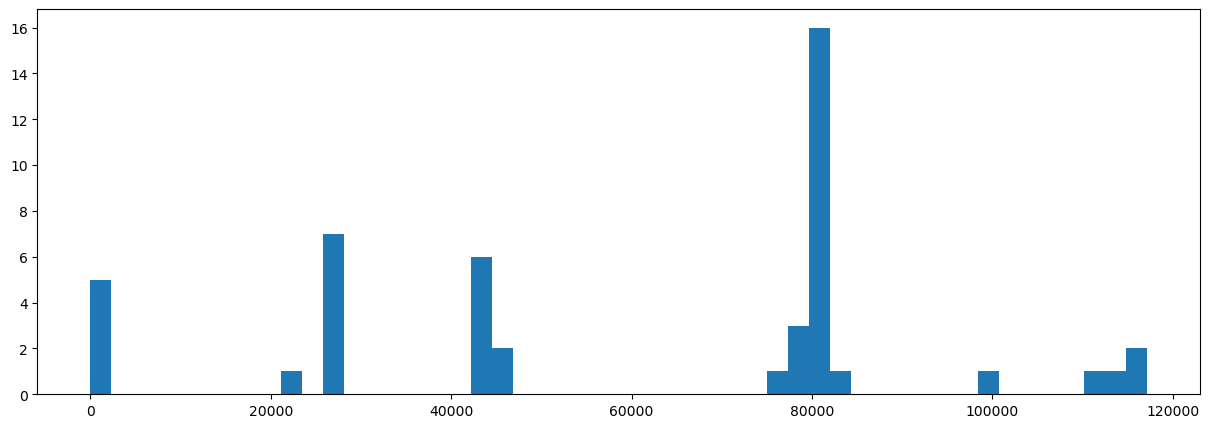

In [67]:
fig = plt.figure(figsize=(15,5))
plt.hist(df_narrow.isnull().sum(), bins=50);

In [68]:
null_props = df_narrow.isnull().sum() / len(df_narrow)

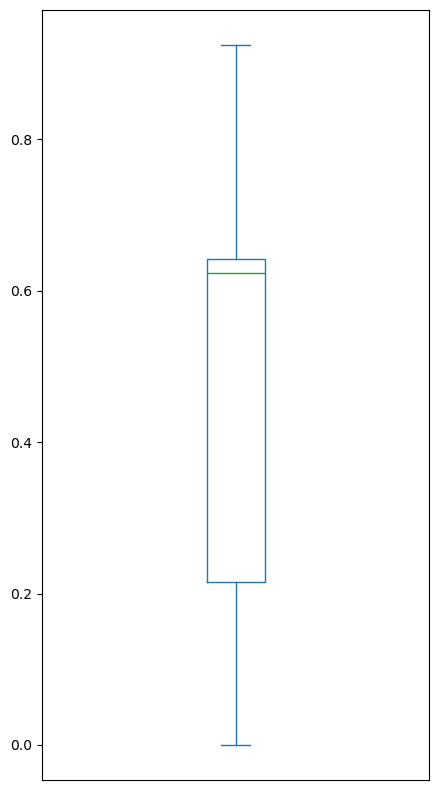

In [69]:
fig = plt.figure(figsize=(5,10))
null_props.plot(kind='box')
plt.xticks([])
plt.show();

Referring back to the full printed list of null counts, we can see that there's actually a decent chunk of people who received the CPS interview, but did not receive the CEV supplement. That supplement is really important to this analysis, so I really only want the data from people who answered it.

In [70]:
df_narrow[df_narrow['prsupint'] != 'Interview'].shape[0] / df_narrow.shape[0]

0.6229029329333281

We'll be dropping 62.3% of the entries from the original dataset to meet this need. We can also drop the `prsupint` column after this, as it won't serve any further purpose.

In [71]:
df_cev = df_narrow[df_narrow['prsupint'] == 'Interview'].drop(columns=['prsupint'])

In [72]:
df_cev.shape

(47765, 46)

In [73]:
null_props = df_cev.isnull().sum() / len(df_cev)

I want to keep columns that are at at least 95% complete, so I will check for that here and drop anything that does not meet that level of completeness.

In [74]:
i = 0

for p in null_props:
    
    if p >= 0.05:
        print(f"{null_props.index[i]}: {p*100:.2f}%")

    i += 1

pemjot: 42.62%
pehruslt: 42.62%
prcowpg: 46.80%
prmjocgr: 40.14%
peernhry: 87.49%
peerncov: 88.79%
peschenr: 48.01%
voterstatus: 5.62%
boycott: 5.29%
org: 5.03%
numorg: 73.27%
politicaldonor: 5.56%
donate: 5.54%
workvol: 45.72%
ffissues: 5.09%
nissues: 5.14%
views: 5.32%
news: 5.19%
volfreq: 69.76%


There are several features here which just barely meet the cutoff, and then a large gap between those and the rest that do not meet that criteria. In the interest of trying to hold onto as many features of interest as possible, which are also mostly complete, I will hold onto the near misses and drop the rest.

In [75]:
i = 0
drops = []

for p in null_props:
    
    if p >= 0.06:
        drops.append(null_props.index[i])

    i += 1

In [76]:
df_cev.drop(columns=drops, inplace=True)

In [77]:
df_cev.shape

(47765, 36)

In [78]:
null_props = df_cev.isnull().sum() / len(df_cev)

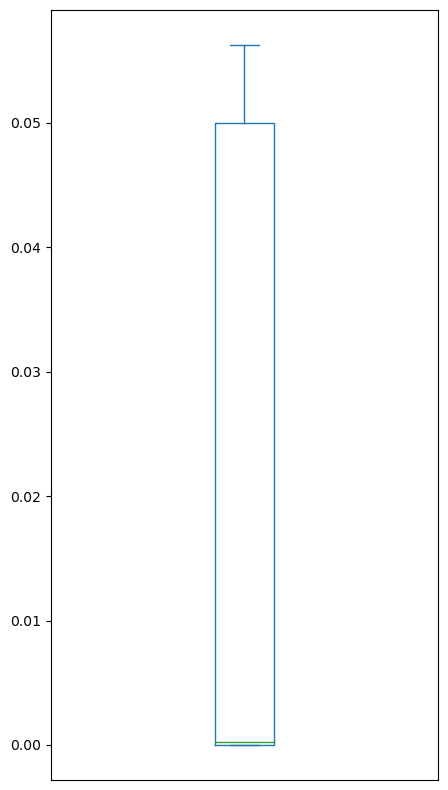

In [79]:
fig = plt.figure(figsize=(5,10))
null_props.plot(kind='box')
plt.xticks([])
plt.show();

In [80]:
df_cev.isnull().sum()

hetenure             0
hehousut             0
hefaminc             0
hrnumhou             0
hubus               23
gereg                0
gtmetsta           553
prtage               0
pemaritl             0
pesex                0
veteran            369
peafnow              0
peeduca              0
ptdtrace             0
pehspnon             0
prcitshp             0
pemlr                0
prcivlf              0
disability           0
action            2251
voterstatus       2686
meeting           2327
contact           2382
boycott           2528
org               2402
politicaldonor    2656
donate            2648
volunteer            0
supwgt               0
fftalk            1940
ffissues          2429
ntalk             2213
nissues           2454
favors            2288
views             2541
news              2478
dtype: int64

Now I will look at rows.

In [81]:
num_missing_row = df_cev.isnull().sum(axis=1)

In [82]:
df_cev.insert(loc=len(df_cev.columns), column='null_count', value=num_missing_row)

In [83]:
print(f"Number of rows: {len(df_cev)}")
print(f"Mean number of missing entries per row: {np.mean(df_cev['null_count']):.3}")
print(f"Median number of missing entries per row: {np.median(df_cev['null_count']):.3}")

Number of rows: 47765
Mean number of missing entries per row: 0.778
Median number of missing entries per row: 0.0


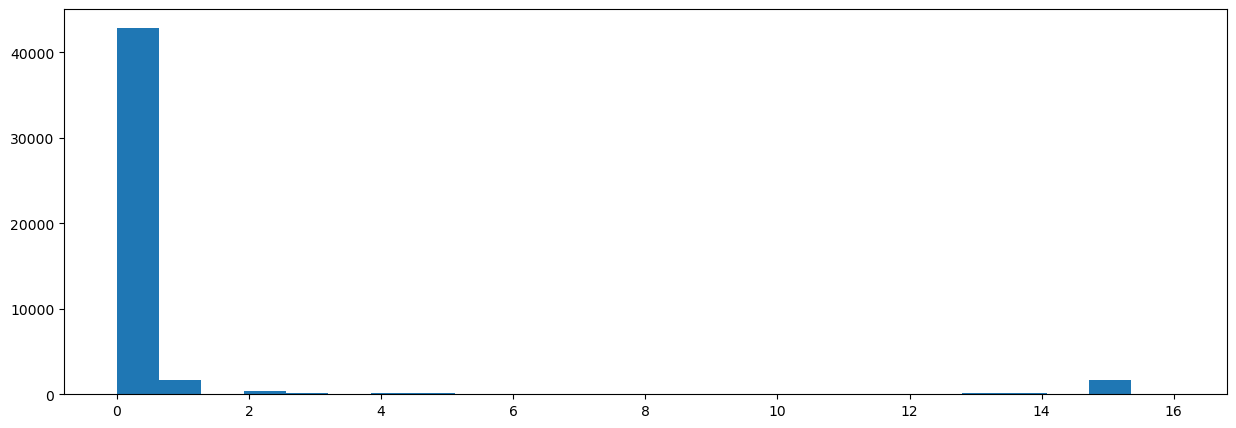

In [84]:
fig = plt.figure(figsize=(15,5))
plt.hist(df_cev['null_count'], bins=25);

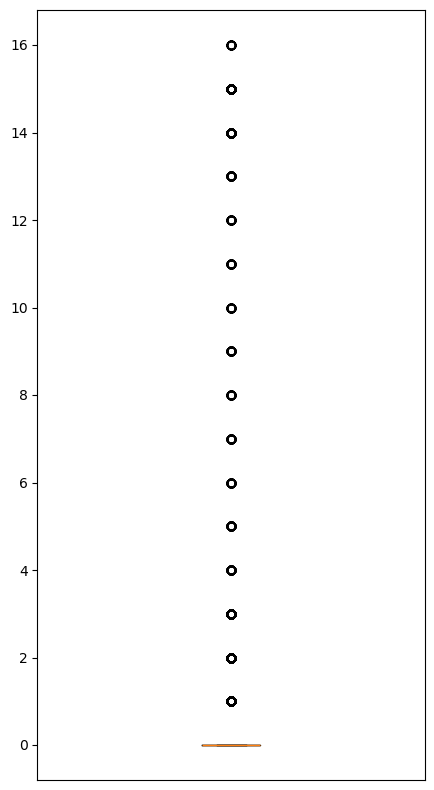

In [85]:
fig = plt.figure(figsize=(5,10))
plt.boxplot(num_missing_row)
plt.xticks([])
plt.show();

In [86]:
df_cev['null_count'].describe()

count    47765.000000
mean         0.778143
std          3.080610
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         16.000000
Name: null_count, dtype: float64

In [87]:
df_cev[df_cev['null_count'] == 0].shape[0] / len(df_cev)

0.8981890505600335

The vast majority of rows at this point are complete or almost complete, to the point that any rows missing any amount of information are seen as outliers on a boxplot. There's a loss of about 10% of the current data if I hold onto just the fully complete data, which is still over 40,000 points of data. TO keep things simple, I will move forward with that set.

In [88]:
df_cev = df_cev[df_cev['null_count'] == 0]

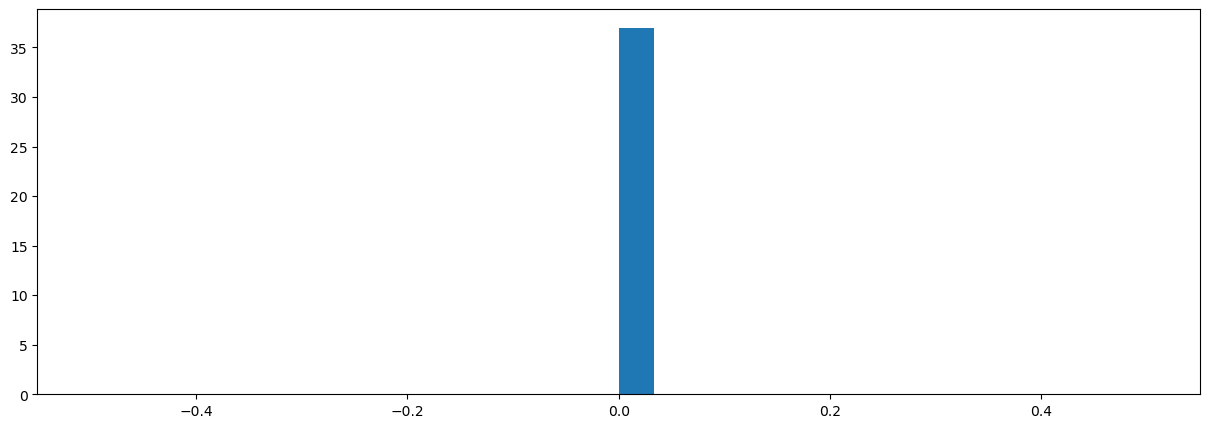

In [89]:
fig = plt.figure(figsize=(15,5))
plt.hist(df_cev.isnull().sum(), bins=30);

In [90]:
df_cev.isnull().sum()

hetenure          0
hehousut          0
hefaminc          0
hrnumhou          0
hubus             0
gereg             0
gtmetsta          0
prtage            0
pemaritl          0
pesex             0
veteran           0
peafnow           0
peeduca           0
ptdtrace          0
pehspnon          0
prcitshp          0
pemlr             0
prcivlf           0
disability        0
action            0
voterstatus       0
meeting           0
contact           0
boycott           0
org               0
politicaldonor    0
donate            0
volunteer         0
supwgt            0
fftalk            0
ffissues          0
ntalk             0
nissues           0
favors            0
views             0
news              0
null_count        0
dtype: int64

Now that the dataset has all complete data, we can drop the `null_count` column and continue to feature encoding.

In [91]:
df_cev.drop(columns=['null_count'], inplace=True)

In [92]:
df_cev.shape

(42902, 36)

We will save this copy of the dataset.

In [93]:
df_cev.to_csv("../data/cleaned/cev_complete.csv", index=False)

## Encoding For Training

Since we're looking to do k-means clustering on this dataset, we need to make sure all features are of a numeric datatype. 

Binary (any format): `hubus`, `gtmetsta`, `pesex`, `veteran`, `peafnow`, `pehspnon`, `prcivlf`, `disability`, `action`, `meeting`, `contact`, `boycott`, `org`, `politicaldonor`, `donate`, `prsupint`, `volunteer`

Numeric: `hrnumhou` (0-16), `supwgt` (excluded from analysis) 

Categorical: `hetenure` (3 categories), `hehousut` (11 categories), `gereg` (4 categories), `pemaritl` (6 categories), `ptdtrace` (26 categories), `prcitshp` (5 categories), `pemlr` (7 categories), `voterstatus` (3 categories)

Ordinal: `peeduca`, `fftalk` (inverse), `ffissues` (inverse), `ntalk` (inverse), `nissues` (inverse), `favors` (inverse), `views` (inverse), `news` (inverse)

Mixed: `prtage` (ordinal until 80, then includes intervals for 80-84, and 85+)

Interval: `hefaminc` (15 intervals)

### Binary Data 

In [94]:
binary = ['hubus', 'gtmetsta', 'pesex', 'veteran', 
          'peafnow', 'pehspnon', 'prcivlf', 'disability', 
          'action', 'meeting', 'contact', 'boycott', 
          'org', 'politicaldonor', 'donate', 'volunteer']

for b in binary:
    print(b)
    print(df_cev[b].unique())
    print('\n')

hubus
<StringArray>
['NO', 'YES']
Length: 2, dtype: str


gtmetsta
<StringArray>
['METROPOLITAN', 'NONMETROPOLITAN']
Length: 2, dtype: str


pesex
<StringArray>
['MALE', 'FEMALE']
Length: 2, dtype: str


veteran
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


peafnow
<StringArray>
['NO']
Length: 1, dtype: str


pehspnon
<StringArray>
['NON-HISPANIC', 'HISPANIC']
Length: 2, dtype: str


prcivlf
<StringArray>
['NOT IN CIVILIAN LABOR FORCE', 'IN CIVILIAN LABOR FORCE']
Length: 2, dtype: str


disability
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


action
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


meeting
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


contact
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


boycott
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


org
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


politicaldonor
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


donate
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


volunteer
<StringA

`peafnow` only has one value represented in the dataset, we can drop that.

In [95]:
df_cev.drop(columns=['peafnow'], inplace=True)

In [96]:
binary.remove('peafnow')

In [97]:
df_cev = pd.get_dummies(df_cev, columns=binary, drop_first=True, dtype=int)

### Ordinal Data

In [98]:
ordinal = ['peeduca', 'fftalk', 'ffissues', 'ntalk', 'nissues', 'favors', 'views', 'news']

for o in ordinal:
    print(o)
    print(df_cev[o].unique())
    print('\n')

peeduca
<StringArray>
[           'ASSOCIATE DEGREE-ACADEMIC PROGRAM',
      'HIGH SCHOOL GRAD-DIPLOMA OR EQUIV (GED)',
 'MASTER'S DEGREE (EX: MA, MS, MEng, MEd, MSW)',
           'BACHELOR'S DEGREE (EX: BA, AB, BS)',
                   'SOME COLLEGE BUT NO DEGREE',
     'ASSOCIATE DEGREE-OCCUPATIONAL/VOCATIONAL',
                                   '11TH GRADE',
                                   '10TH GRADE',
                        '12TH GRADE NO DIPLOMA',
              'DOCTORATE DEGREE (EX: PhD, EdD)',
                   '1ST, 2ND, 3RD OR 4TH GRADE',
                                    '9TH GRADE',
   'PROFESSIONAL SCHOOL DEG (EX: MD, DDS, DVM)',
                             '7TH OR 8TH GRADE',
                             '5TH OR 6TH GRADE',
                          'LESS THAN 1ST GRADE']
Length: 16, dtype: str


fftalk
<StringArray>
[    'A few times a week',    'Basically every day',    'A few times a month',
 'Less than once a month',             'Not at all',           'Once 

All but `peeduca` use the same six-level scale for responses, so I will map a list of ordered values to those responses.

In [99]:
survey_scale= {
    'Not at all':0,
    'Less than once a month':1,
    'Once a month':2,
    'A few times a month':3,
    'A few times a week':4,
    'Basically every day':5}

In [100]:
survey_qs = ordinal[1:]

In [101]:
df_cev[survey_qs].head()

,fftalk,ffissues,ntalk,nissues,favors,views,news
0,A few times a week,Once a month,A few times a month,Once a month,A few times a week,Not at all,Basically every day
6,Basically every day,Basically every day,A few times a week,A few times a week,Once a month,Once a month,Basically every day
7,Basically every day,A few times a month,A few times a week,A few times a week,Once a month,Basically every day,Basically every day
8,Basically every day,A few times a week,A few times a week,A few times a month,Less than once a month,Not at all,Basically every day
9,Basically every day,Less than once a month,A few times a week,Less than once a month,Less than once a month,Not at all,Basically every day


In [102]:
for q in survey_qs:
    df_cev[q + "_encoded"] = df_cev[q].map(survey_scale)
    df_cev.drop(columns=[q], inplace=True)

In [103]:
df_cev.shape

(42902, 35)

In [104]:
df_cev.iloc[:5,31:]

,nissues_encoded,favors_encoded,views_encoded,news_encoded
0,2,4,0,5
6,4,2,2,5
7,4,2,5,5
8,3,1,0,5
9,1,1,0,5


Now I'll do a seperate mapping for `peeduca`.

In [105]:
edu_scale = {
    'LESS THAN 1ST GRADE':0,
    '1ST, 2ND, 3RD OR 4TH GRADE':1,
    '5TH OR 6TH GRADE':2,
    '7TH OR 8TH GRADE':3,
    '9TH GRADE':4,
    '10TH GRADE':5,
    '11TH GRADE':6,
    '12TH GRADE NO DIPLOMA':7,
    'HIGH SCHOOL GRAD-DIPLOMA OR EQUIV (GED)':8,
    'SOME COLLEGE BUT NO DEGREE':9,
    'ASSOCIATE DEGREE-OCCUPATIONAL/VOCATIONAL':10,
    'ASSOCIATE DEGREE-ACADEMIC PROGRAM':11,
    'BACHELOR\'S DEGREE (EX: BA, AB, BS)':12,
    'MASTER\'S DEGREE (EX: MA, MS, MEng, MEd, MSW)':13,
    'PROFESSIONAL SCHOOL DEG (EX: MD, DDS, DVM)':14,
    'DOCTORATE DEGREE (EX: PhD, EdD)':15
}

In [106]:
df_cev['peeduca'].head(10)

0                ASSOCIATE DEGREE-ACADEMIC PROGRAM
6          HIGH SCHOOL GRAD-DIPLOMA OR EQUIV (GED)
7                ASSOCIATE DEGREE-ACADEMIC PROGRAM
8     MASTER'S DEGREE (EX: MA, MS, MEng, MEd, MSW)
9               BACHELOR'S DEGREE (EX: BA, AB, BS)
10    MASTER'S DEGREE (EX: MA, MS, MEng, MEd, MSW)
11              BACHELOR'S DEGREE (EX: BA, AB, BS)
17                      SOME COLLEGE BUT NO DEGREE
18        ASSOCIATE DEGREE-OCCUPATIONAL/VOCATIONAL
19         HIGH SCHOOL GRAD-DIPLOMA OR EQUIV (GED)
Name: peeduca, dtype: str

In [107]:
df_cev['ed_level_encoded'] = df_cev['peeduca'].map(edu_scale)

In [108]:
unique_pairs = df_cev[['peeduca', 'ed_level_encoded']].drop_duplicates()
print(unique_pairs)

                                          peeduca  ed_level_encoded
0               ASSOCIATE DEGREE-ACADEMIC PROGRAM                11
6         HIGH SCHOOL GRAD-DIPLOMA OR EQUIV (GED)                 8
8    MASTER'S DEGREE (EX: MA, MS, MEng, MEd, MSW)                13
9              BACHELOR'S DEGREE (EX: BA, AB, BS)                12
17                     SOME COLLEGE BUT NO DEGREE                 9
18       ASSOCIATE DEGREE-OCCUPATIONAL/VOCATIONAL                10
37                                     11TH GRADE                 6
53                                     10TH GRADE                 5
160                         12TH GRADE NO DIPLOMA                 7
163               DOCTORATE DEGREE (EX: PhD, EdD)                15
195                    1ST, 2ND, 3RD OR 4TH GRADE                 1
197                                     9TH GRADE                 4
235    PROFESSIONAL SCHOOL DEG (EX: MD, DDS, DVM)                14
318                              7TH OR 8TH GRAD

In [109]:
df_cev.drop(columns=['peeduca'], inplace=True)

In [110]:
df_cev.shape

(42902, 35)

### Mixed /Interval Data

In [111]:
print(df_cev['prtage'].unique())

<StringArray>
[  '85+ Years Old',              '68',              '73',              '78',
              '75',              '74',              '72',              '57',
              '32',              '70',              '51',              '17',
              '41',              '48',              '71',              '59',
              '36',              '64',              '19',              '38',
              '39',              '76', '80-84 Years Old',              '25',
              '31',              '24',              '54',              '56',
              '77',              '55',              '53',              '65',
              '67',              '62',              '40',              '69',
              '60',              '45',              '27',              '18',
              '43',              '50',              '30',              '61',
              '35',              '28',              '63',              '66',
              '52',              '79',              '21',     

Because this includes some strings, this mostly numerical series is all string-typed. I want to do a couple things here:

- Create even intervals of 10-year groups for all values to fit within
- Map those values to numeric representations

I will manually replace the existing ranges with appropriate integer values, then re-type the whole column as an integer type.

In [112]:
df_cev.replace({'prtage':{'80-84 Years Old':'82', '85+ Years Old':'85'}}, inplace=True);

In [113]:
df_cev['prtage'] = df_cev['prtage'].astype(int)

Now I can map ranges of integers to respective ordinal levels. I will be using a mask of age intervals to set values.

In [114]:
df_cev['age_encoded'] = 0

In [115]:
age = 15
for a in range(1,9):
    mask = df_cev['prtage'].between(age, age + 9)
    df_cev.loc[mask, 'age_encoded'] = a
    age += 10

In [116]:
df_cev.drop(columns=['prtage'], inplace=True)

Now let's look at the income bracket intervals.

In [117]:
print(df_cev['hefaminc'].unique())

<StringArray>
[  '50,000 TO 59,999',   '40,000 TO 49,999',   '75,000 TO 99,999',
   '25,000 TO 29,999',   '30,000 TO 34,999',   '20,000 TO 24,999',
   '60,000 TO 74,999',   '15,000 TO 19,999',     '5,000 TO 7,499',
    '150,000 OR MORE', '100,000 TO 149,999',   '12,500 TO 14,999',
   '10,000 TO 12,499',   '35,000 TO 39,999',   'LESS THAN $5,000',
     '7,500 TO 9,999']
Length: 16, dtype: str


Part of the issue here is the intervals are not evenly spaced. I will be setting my mapping such that the numeric representation increases roughly every 30k (as the existing intervals allow) as a general scale of economic bracketing, without accounting for household size:

- <5k - 30k -> Lower Class
- 30k - 60k -> Lower-Middle Class
- 60k - 100k -> Middle Class
- 100k - 150k -> Upper-Middle Class
- \>150k -> Upper Class.

In [118]:
income_scale = {
    'LESS THAN $5,000':1,
    '5,000 TO 7,499':1,
    '7,500 TO 9,999':1,
    '10,000 TO 12,499':1,
    '12,500 TO 14,999':1,
    '15,000 TO 19,999':1,
    '20,000 TO 24,999':1,
    '25,000 TO 29,999':1,
    '30,000 TO 34,999':2,
    '35,000 TO 39,999':2,
    '40,000 TO 49,999':2,
    '50,000 TO 59,999':2,
    '60,000 TO 74,999':3,
    '75,000 TO 99,999':3,
    '100,000 TO 149,999':4,
    '150,000 OR MORE':5
}

In [119]:
df_cev['hhincome_encoded'] = df_cev['hefaminc'].map(income_scale)

In [120]:
unique_pairs = df_cev[['hefaminc', 'hhincome_encoded']].drop_duplicates()
print(unique_pairs)

               hefaminc  hhincome_encoded
0      50,000 TO 59,999                 2
6      40,000 TO 49,999                 2
8      75,000 TO 99,999                 3
17     25,000 TO 29,999                 1
19     30,000 TO 34,999                 2
23     20,000 TO 24,999                 1
36     60,000 TO 74,999                 3
46     15,000 TO 19,999                 1
53       5,000 TO 7,499                 1
57      150,000 OR MORE                 5
67   100,000 TO 149,999                 4
81     12,500 TO 14,999                 1
83     10,000 TO 12,499                 1
218    35,000 TO 39,999                 2
274    LESS THAN $5,000                 1
362      7,500 TO 9,999                 1


In [121]:
df_cev.drop(columns=['hefaminc'], inplace=True)

### Categorical Data

In [122]:
categorical = ['hetenure', 'hehousut', 'gereg', 'pemaritl', 'ptdtrace', 'prcitshp', 'pemlr', 'voterstatus']

for c in categorical:
    print(c)
    print(df_cev[c].unique())
    print('\n')

hetenure
<StringArray>
[ 'OWNED OR BEING BOUGHT BY A HH MEMBER',
                       'RENTED FOR CASH',
 'OCCUPIED WITHOUT PAYMENT OF CASH RENT']
Length: 3, dtype: str


hehousut
<StringArray>
[                              'HOUSE, APARTMENT, FLAT',
         'MOBILE HOME OR TRAILER W/NO PERM. ROOM ADDED',
 'MOBILE HOME OR TRAILER W/1 OR MORE PERM. ROOMS ADDED',
                       'OTHER UNIT NOT SPECIFIED ABOVE',
                               'HU NOT SPECIFIED ABOVE',
                'HU IN NONTRANSIENT HOTEL, MOTEL, ETC.',
                                  'HU IN ROOMING HOUSE',
               'HU PERMANENT IN TRANSIENT HOTEL, MOTEL',
              'QUARTERS NOT HU IN ROOMING OR BRDING HS']
Length: 9, dtype: str


gereg
<StringArray>
['SOUTH', 'NORTHEAST', 'MIDWEST (FORMERLY NORTH CENTRAL)', 'WEST']
Length: 4, dtype: str


pemaritl
<StringArray>
[                 'WIDOWED', 'MARRIED - SPOUSE PRESENT',
                 'DIVORCED',            'NEVER MARRIED',
  'MARRIED - SPOUSE

There are a few features here that I want to make bigger adjustments to before encoding:

- I want to simplify `ptdtrace` such that it is boiled down to | specific single race | biracial | multiracial |
- I want to condense `prcitshp` to split into | Citizen | Non | Naturalized |
- I want to condense `pemlr` a few ways, resulting in a simplified split of | Employed | Unemployed | Not Working |
    - Part of my desire to combine the 'not in labor force' responses into one is to reduce collinearity with the `disabled` binary feature we are already including.
- `hrhousut` can also be simplified into a few categories: | house | mobile | unit | other |

There are also some values I will want to rename or otherwise combine so dummies are easier to parse and access.

In [123]:
import re

Seperating `ptdtrace` values will be simple using a very basic regex search. All biracial entries use a single hyphen to seperate which races the individual are, and multiple hyphens for multiracial (and also a string entry for folks with many races). I will track index locations for each 2+ race entry in a couple of lists and use those to overwrite the simplifies values.

In [124]:
biracial = []
multiracial = []

for _ in df_cev.index:
    count = len(re.findall("-", df_cev.loc[_, 'ptdtrace']))
    
    if count == 1:
        biracial.append(_)
    elif count > 1:
        multiracial.append(_)
    elif df_cev.loc[_, 'ptdtrace'] == 'Other 4 and 5 Race Combinations':
        multiracial.append(_)
    else:
        pass

In [125]:
print(f'{len(biracial)}, {len(multiracial)}')

702, 68


In [126]:
df_cev['simrace'] = df_cev['ptdtrace']

In [127]:
df_cev.loc[biracial, 'simrace'] = 'Biracial'

In [128]:
df_cev.loc[multiracial, 'simrace'] = 'Multiracial'

I'm also going to drop the ' Only' part of the single race values, it's uncessecary and looks nicer without it. 'American Indian, Alaskan Native' and 'Hawaiian/Pacific Islander' will be reduced to initialism 'AIAN' and 'HPI' respectively to save visual space.

In [129]:
df_cev['simrace'] = df_cev['simrace'].str.replace({' Only': '', 'American Indian, Alaskan Native': 'AIAN', 'Hawaiian/Pacific Islander':'HPI'})

In [130]:
df_cev['simrace'].unique()

<StringArray>
['White', 'Black', 'Multiracial', 'Biracial', 'Asian', 'AIAN', 'HPI']
Length: 7, dtype: str

In [131]:
unique_pairs = df_cev[['ptdtrace', 'simrace']].drop_duplicates()
print(unique_pairs)

                                   ptdtrace      simrace
0                                White Only        White
23                               Black Only        Black
53                                   W-B-AI  Multiracial
103                                White-AI     Biracial
172                             White-Black     Biracial
338                              Asian Only        Asian
694    American Indian, Alaskan Native Only         AIAN
1008                            White-Asian     Biracial
1298                               Black-AI     Biracial
1936         Hawaiian/Pacific Islander Only          HPI
5563                                 W-AI-A  Multiracial
6215                               W-B-AI-A  Multiracial
7538                               Asian-HP     Biracial
7886                                  AI-HP     Biracial
8045                               White-HP     Biracial
10079                              Black-HP     Biracial
10085                          

In [132]:
df_cev.drop(columns=['ptdtrace'], inplace=True)

In [133]:
categorical.remove('ptdtrace')
categorical.append('simrace')

Condensing `prcitshp`.

In [134]:
df_cev['citizen_type'] = df_cev['prcitshp']

In [135]:
idx = df_cev.index
i = 0

for c in df_cev['citizen_type']:
    if 'NATIVE' in c:
        df_cev.loc[idx[i], 'citizen_type'] = 'Citizen'
    elif 'NATURALIZATION' in c:
        df_cev.loc[idx[i], 'citizen_type'] = 'Naturalized'
    else:
        df_cev.loc[idx[i], 'citizen_type'] = 'Non'

    i += 1

In [136]:
unique_pairs = df_cev[['prcitshp', 'citizen_type']].drop_duplicates()
print(unique_pairs)

                                              prcitshp citizen_type
0                    NATIVE, BORN IN THE UNITED STATES      Citizen
188  NATIVE, BORN IN PUERTO RICO OR OTHER U.S. ISLA...      Citizen
191   FOREIGN BORN, NOT A CITIZEN OF THE UNITED STATES          Non
199  NATIVE, BORN ABROAD OF AMERICAN PARENT OR PARENTS      Citizen
282       FOREIGN BORN, U.S. CITIZEN BY NATURALIZATION  Naturalized


In [137]:
df_cev.drop(columns=['prcitshp'], inplace=True)
categorical.remove('prcitshp')
categorical.append('citizen_type')

Now adjusting `pemlr` values.

In [139]:
df_cev['work_status'] = df_cev['pemlr'].str.replace({
    'NOT IN LABOR FORCE-RETIRED': 'Not Working',
    'NOT IN LABOR FORCE-DISABLED': 'Not Working',
    'NOT IN LABOR FORCE-OTHER': 'Not Working',
    'EMPLOYED-AT WORK': 'Employed',
    'EMPLOYED-ABSENT': 'Employed',
    'UNEMPLOYED-LOOKING': 'Unemployed',
    'UNEMPLOYED-ON LAYOFF': 'Unemployed'
})

In [140]:
unique_pairs = df_cev[['pemlr', 'work_status']].drop_duplicates()
print(unique_pairs)

                           pemlr  work_status
0     NOT IN LABOR FORCE-RETIRED  Not Working
17   NOT IN LABOR FORCE-DISABLED  Not Working
18              EMPLOYED-AT WORK     Employed
37      NOT IN LABOR FORCE-OTHER  Not Working
191              EMPLOYED-ABSENT     Employed
309           UNEMPLOYED-LOOKING   Unemployed
658         UNEMPLOYED-ON LAYOFF   Unemployed


In [141]:
df_cev.drop(columns=['pemlr'], inplace=True)
categorical.remove('pemlr')
categorical.append('work_status')

Finally, looking at housing unit types.

In [142]:
df_cev['housing_unit'] = df_cev['hehousut']

In [143]:
idx = df_cev.index
i = 0

for h in df_cev['housing_unit']:
    if 'FLAT' in h:
        df_cev.loc[idx[i], 'housing_unit'] = 'House'
    elif 'MOBILE' in h:
        df_cev.loc[idx[i], 'housing_unit'] = 'Mobile'
    elif 'HU' in h:
        df_cev.loc[idx[i], 'housing_unit'] = 'Unit'
    else:
        df_cev.loc[idx[i], 'housing_unit'] = 'Other'

    i += 1


In [144]:
unique_pairs = df_cev[['hehousut', 'housing_unit']].drop_duplicates()
print(unique_pairs)

                                                hehousut housing_unit
0                                 HOUSE, APARTMENT, FLAT        House
17          MOBILE HOME OR TRAILER W/NO PERM. ROOM ADDED       Mobile
853    MOBILE HOME OR TRAILER W/1 OR MORE PERM. ROOMS...       Mobile
1809                      OTHER UNIT NOT SPECIFIED ABOVE        Other
5888                              HU NOT SPECIFIED ABOVE         Unit
5906               HU IN NONTRANSIENT HOTEL, MOTEL, ETC.         Unit
16060                                HU IN ROOMING HOUSE         Unit
21742             HU PERMANENT IN TRANSIENT HOTEL, MOTEL         Unit
41800            QUARTERS NOT HU IN ROOMING OR BRDING HS         Unit


In [145]:
df_cev.drop(columns=['hehousut'], inplace=True)
categorical.remove('hehousut')
categorical.append('housing_unit')

Now we'll do a little adjusting to pretty much every other categorical feature to make them more coherent after being encoded.

`hetenure`:

In [146]:
ownership_map = {
    'OWNED OR BEING BOUGHT BY A HH MEMBER': 'Owned',
    'RENTED FOR CASH': 'Rented',
    'OCCUPIED WITHOUT PAYMENT OF CASH RENT': 'Free'
}

df_cev['hetenure'] = df_cev['hetenure'].map(ownership_map)

In [147]:
df_cev['hetenure'].unique()

<StringArray>
['Owned', 'Rented', 'Free']
Length: 3, dtype: str

`gereg`:

In [148]:
df_cev['gereg'] = df_cev['gereg'].str.replace(' (FORMERLY NORTH CENTRAL)', '')

In [149]:
df_cev['gereg'].unique()

<StringArray>
['SOUTH', 'NORTHEAST', 'MIDWEST', 'WEST']
Length: 4, dtype: str

`pemaritl`:

In [150]:
df_cev['pemaritl'] = df_cev['pemaritl'].replace(['MARRIED - SPOUSE PRESENT', 'MARRIED - SPOUSE ABSENT'], 'MARRIED')

In [151]:
df_cev['pemaritl'].unique()

<StringArray>
['WIDOWED', 'MARRIED', 'DIVORCED', 'NEVER MARRIED', 'SEPARATED']
Length: 5, dtype: str

`voterstatus`:

In [152]:
df_cev['voterstatus'] = df_cev['voterstatus'].replace('Not eligible to vote', 'NA')

In [153]:
df_cev['voterstatus'].unique()

<StringArray>
['No', 'Yes', 'NA']
Length: 3, dtype: str

Now we can dummy all the categoricals.

In [154]:
df_cev_encoded = pd.get_dummies(df_cev, columns=categorical, dtype=int) 

In [155]:
df_cev_encoded.head()

,hrnumhou,supwgt,hubus_YES,gtmetsta_NONMETROPOLITAN,pesex_MALE,veteran_Yes,pehspnon_NON-HISPANIC,prcivlf_NOT IN CIVILIAN LABOR FORCE,disability_Yes,action_Yes,...,citizen_type_Citizen,citizen_type_Naturalized,citizen_type_Non,work_status_Employed,work_status_Not Working,work_status_Unemployed,housing_unit_House,housing_unit_Mobile,housing_unit_Other,housing_unit_Unit
0,2,2231.7972,0,0,1,1,1,1,1,0,...,1,0,0,0,1,0,1,0,0,0
6,2,3664.3063,0,0,0,0,1,1,1,0,...,1,0,0,0,1,0,1,0,0,0
7,2,2915.8868,0,0,1,0,1,1,1,0,...,1,0,0,0,1,0,1,0,0,0
8,2,2153.5261,0,0,1,1,1,1,0,0,...,1,0,0,0,1,0,1,0,0,0
9,2,2813.6261,0,0,0,0,1,1,0,0,...,1,0,0,0,1,0,1,0,0,0


Making sure all columns are now numeric:

In [156]:
df_cev_encoded.dtypes.value_counts()

int64      58
float64     1
Name: count, dtype: int64

The last thing I want to do is split these sets by volunteer / non-volunteer groups since I want to find segments of both.

In [157]:
df_volunteer = df_cev_encoded[df_cev_encoded['volunteer_Yes'] == 1].drop(columns=['volunteer_Yes']).reset_index(drop=True)
df_nonvolunteer = df_cev_encoded[df_cev_encoded['volunteer_Yes'] == 0].drop(columns=['volunteer_Yes']).reset_index(drop=True)                                                 

In [158]:
df_volunteer.info()

<class 'pandas.DataFrame'>
RangeIndex: 13724 entries, 0 to 13723
Data columns (total 58 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   hrnumhou                             13724 non-null  int64  
 1   supwgt                               13724 non-null  float64
 2   hubus_YES                            13724 non-null  int64  
 3   gtmetsta_NONMETROPOLITAN             13724 non-null  int64  
 4   pesex_MALE                           13724 non-null  int64  
 5   veteran_Yes                          13724 non-null  int64  
 6   pehspnon_NON-HISPANIC                13724 non-null  int64  
 7   prcivlf_NOT IN CIVILIAN LABOR FORCE  13724 non-null  int64  
 8   disability_Yes                       13724 non-null  int64  
 9   action_Yes                           13724 non-null  int64  
 10  meeting_Yes                          13724 non-null  int64  
 11  contact_Yes                          13

In [159]:
df_nonvolunteer.info()

<class 'pandas.DataFrame'>
RangeIndex: 29178 entries, 0 to 29177
Data columns (total 58 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   hrnumhou                             29178 non-null  int64  
 1   supwgt                               29178 non-null  float64
 2   hubus_YES                            29178 non-null  int64  
 3   gtmetsta_NONMETROPOLITAN             29178 non-null  int64  
 4   pesex_MALE                           29178 non-null  int64  
 5   veteran_Yes                          29178 non-null  int64  
 6   pehspnon_NON-HISPANIC                29178 non-null  int64  
 7   prcivlf_NOT IN CIVILIAN LABOR FORCE  29178 non-null  int64  
 8   disability_Yes                       29178 non-null  int64  
 9   action_Yes                           29178 non-null  int64  
 10  meeting_Yes                          29178 non-null  int64  
 11  contact_Yes                          29

Now I will save those dataframes to be used for model creation in another notebook.

In [160]:
df_cev_encoded.to_csv('../data/processed/cev_encoded.csv', index=False)

In [161]:
df_volunteer.to_csv('../data/processed/cev_volunteers.csv', index=False)
df_nonvolunteer.to_csv('../data/processed/cev_nonvolunteers.csv', index=False)